<a href="https://colab.research.google.com/github/martuza99/RAC_STS_modeling/blob/main/STS_modeling_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/STS Prediction

/content/drive/MyDrive/Colab Notebooks/STS Prediction


In [ ]:
#normalization of interpoleted data
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

file_name_all=['data2']

otpt_num=1 #how many output we want to model
inpt_num=10 #how many input


output_name=["" for x in range(otpt_num)]
nrm_matrix=np.zeros((2*(inpt_num+1),otpt_num))

y=0

for f in file_name_all:

  data = pd.read_csv(f+'.csv')
  dataset=data.values

  cols_name=list(data.columns.values)
  output_name[y]=cols_name[inpt_num] #saving the output column name

  scaler = StandardScaler()
  scaler.fit(data)
  data_scale = scaler.transform(data)

  nrm_matrix[0:len(dataset[0]),y]=scaler.mean_
  nrm_matrix[len(dataset[0]):2*len(dataset[0]),y]=np.sqrt(scaler.var_)

  file_name='Normalized_'+f
  my_submission = pd.DataFrame(data_scale, columns =cols_name)
  my_submission.to_csv('{}.csv'.format(file_name),index=False)

  y=y+1

file_name='Normalizing_parameters'
my_submission = pd.DataFrame(nrm_matrix, columns  = output_name)
my_submission.to_csv('{}.csv'.format(file_name),index=False)

In [ ]:
#normalization of original data (when one y exist)
import numpy as np
import pandas as pd
from numpy import transpose


cols=11 #no. of input cols+1

out='Y'# 'Y' if there are output also in the dataset  or 'N'

y=0 #0=Prd, 1=OR, 2=NR, 3=PR


output_name=['Prd',	'OR',	'NR', 'PR']
f_name='Data-AMBR_ori_v3_pp_num_'+output_name[y]
data = pd.read_csv(f_name+'.csv')
dataset=data.values

cols_name=list(data.columns.values)
rows=len(dataset)


norm_pers = pd.read_csv('Normalizing_parameters.csv')
normps = norm_pers.values

normd_Prd=np.zeros([rows,cols])
normd_OR=normd_Prd+3
normd_NR=normd_Prd+5
normd_PR=normd_Prd+7

array_list = [normd_Prd, normd_OR, normd_NR, normd_PR]

for x in range(cols-1):
  array_list[y][:,x]=(dataset[:,x]-normps[x,y])/normps[x+cols,y]


if out=='Y':
  array_list[y][:,cols-1]=(dataset[:,cols-1]-normps[cols-1,y])/normps[2*cols-1,y] #normalizing the output column  (when one y exist)
  print(dataset[0,cols-1]) #(when one y exist)

file_name='Normalized_'+f_name
my_submission2 = pd.DataFrame(array_list[y],columns=np.concatenate((cols_name[0:cols-1],[cols_name[cols-1]])))  #(when one y exist)
my_submission2.to_csv('{}.csv'.format(file_name),index=False)

4.3


In [ ]:
#Stratified k-Fold cross-validation

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold


inpt_cols=10
name="STS"
data = pd.read_csv('Normalized_data2.csv')


cols_name=list(data.columns.values)

dataset= data.values
X = dataset[:,0:inpt_cols]
Y = dataset[:,inpt_cols]

skf = StratifiedKFold(n_splits=5,shuffle=True)
Y_cat = pd.cut(Y, 15, labels=range(15))

fold_no=1
X_tra={}
X_tes={}
Y_tra={}
Y_tes={}

for train_index, test_index in skf.split(X, Y_cat):
    print("TRAIN:", train_index, "TEST:", test_index)
    X_tra[fold_no], X_tes[fold_no] = X[train_index], X[test_index]
    Y_tra[fold_no], Y_tes[fold_no] = Y[train_index], Y[test_index]


    file_name=f'Training_data_{name}-fold{fold_no}'
    my_submission1 = pd.DataFrame(np.column_stack((X[train_index],Y[train_index])),columns=cols_name)
    my_submission1.to_csv('{}.csv'.format(file_name),index=False)


    file_name=f'Testing_data_{name}-fold{fold_no}'
    my_submission2 = pd.DataFrame(np.column_stack((X[test_index],Y[test_index])),columns=cols_name)
    my_submission2.to_csv('{}.csv'.format(file_name),index=False)

    fold_no=fold_no+1

TRAIN: [  0   1   2   3   4   9  10  11  12  13  14  15  16  17  19  20  21  22
  23  24  25  26  27  28  29  30  31  32  34  35  37  38  39  40  41  43
  47  48  49  50  51  52  53  54  55  56  59  62  63  64  65  66  67  68
  69  70  71  72  74  75  76  77  78  79  80  81  82  84  85  88  89  90
  91  93  96  98  99 100 101 102 103 104 106 107 110 111 112 113 114 115
 117 118 119 120 121 122 123 124 125 126 127 128 130 131 132 133 134 135
 136 138 140 141 142 143 145 146 147 148 149 150 152 153 154 155 158 160
 161 162 163 164 165 166 167 168 169 170 171 173 174 175 176 177 178 179
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 204 205 206 207 208 210 211 212 215 216 217 219 220 221
 223 224 225 227 228 229 230 231 233 235 236 237 238 239 241 243 244 245
 248 250 251 252] TEST: [  5   6   7   8  18  33  36  42  44  45  46  57  58  60  61  73  83  86
  87  92  94  95  97 105 108 109 116 129 137 139 144 151 156 157 159 172
 180 203 209 213 214

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
# 1 model without pre-training and no drop_off
from keras.models import Sequential
from keras.layers import Dense
import keras_tuner
from keras_tuner import HyperModel, Hyperband
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, optimizers

actf='relu' #'relu' 'tanh' 'sigmoid'
nmin=8
nmax=128 #256#128
nstp=8
lr=1e-2 #1e-2 1e-3 1e-1

#8-64-96-40

def build(hp):
    model = Sequential()
    model.add(layers.Flatten())

    #min_value=80, max_value=128, step=8
    model.add(
        layers.Dense(
            units=hp.Int('units1', min_value=nmin, max_value=nmax, step=nstp),
            kernel_initializer='GlorotUniform',
            activation=actf
        )
    )

    #min_value=48, max_value=96, step=8
    model.add(
        layers.Dense(
            units=hp.Int('units2', min_value=nmin, max_value=nmax, step=nstp),
            kernel_initializer='GlorotUniform',
            activation=actf
        )
    )

    #min_value=8, max_value=54, step=8
    model.add(
        layers.Dense(
            units=hp.Int('units3', min_value=nmin, max_value=nmax, step=nstp),
            kernel_initializer='GlorotUniform',
            activation=actf
        )
    )

    #min_value=8, max_value=54, step=8
    model.add(
        layers.Dense(
            units=hp.Int('units4', min_value=nmin, max_value=nmax, step=nstp),
            kernel_initializer='GlorotUniform',
            activation=actf
        )
    )

    model.add(Dense(1, activation='linear'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),loss='mse',metrics=['mse']
    )
    return model

In [ ]:
#Run it!!
import keras_tuner

build(keras_tuner.HyperParameters())

<Sequential name=sequential, built=False>

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2254 - mse: 0.2254 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2197 - mse: 0.2197 


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2516 - mse: 0.2516 


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2471 - mse: 0.2471 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2586 - mse: 0.2586 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2459 - mse: 0.2459 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2674 - mse: 0.2674 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2839 - mse: 0.2839 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2904 - mse: 0.2904 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.3108 - mse: 0.3108 
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_112-96_k_1_bys_val_0.19567
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Mean absolute error = 0.275
Mean squared error = 0.196
Median absolute error = 0.143
Variance score = 0.1956
Explained variance score = 0.806
R2 score = 0.806


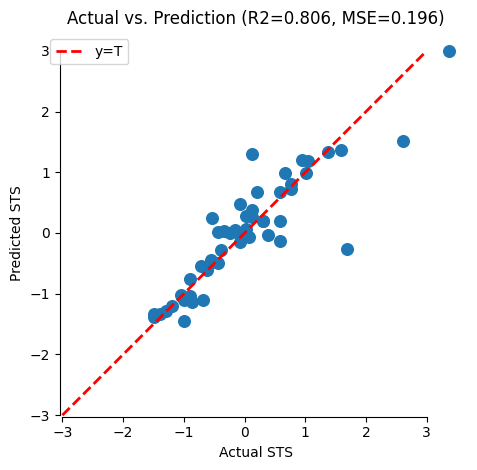

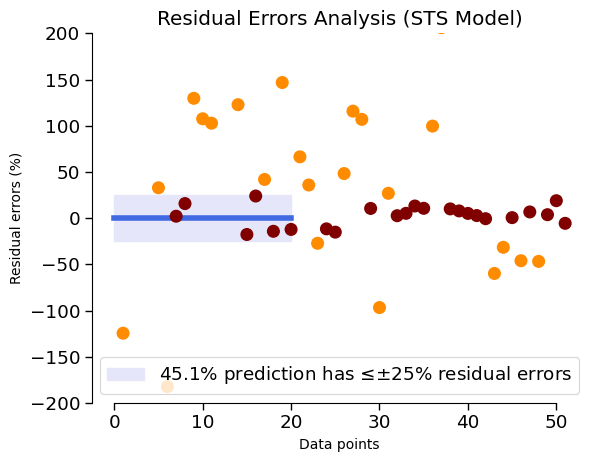

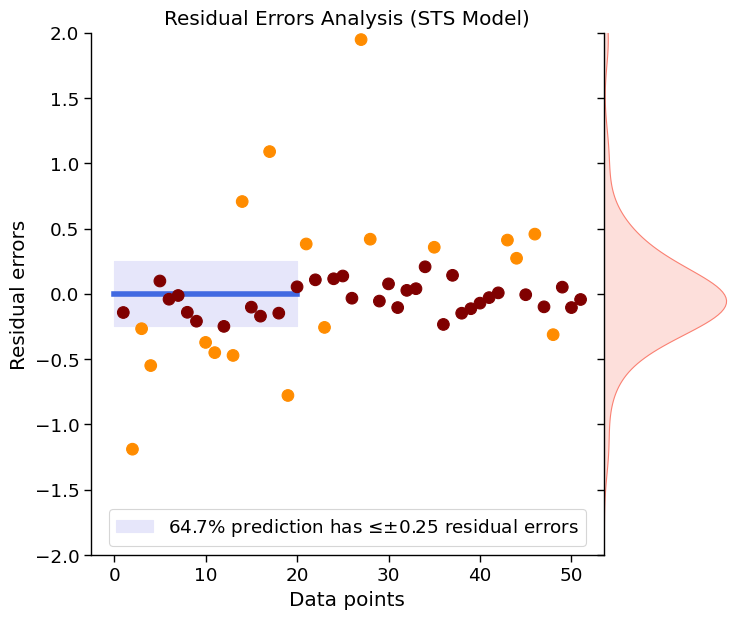

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_64-128_k_1_bys_val_0.19874
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Mean absolute error = 0.307
Mean squared error = 0.199
Median absolute error = 0.212
Variance score = 0.1988
Explained variance score = 0.803
R2 score = 0.803


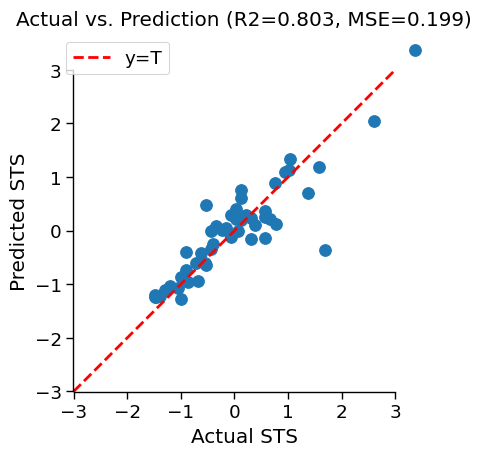

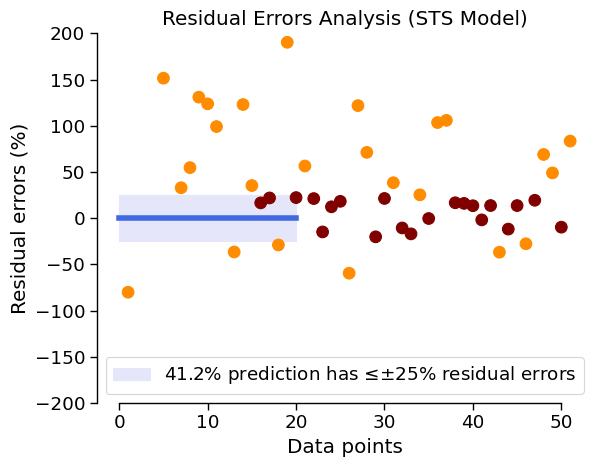

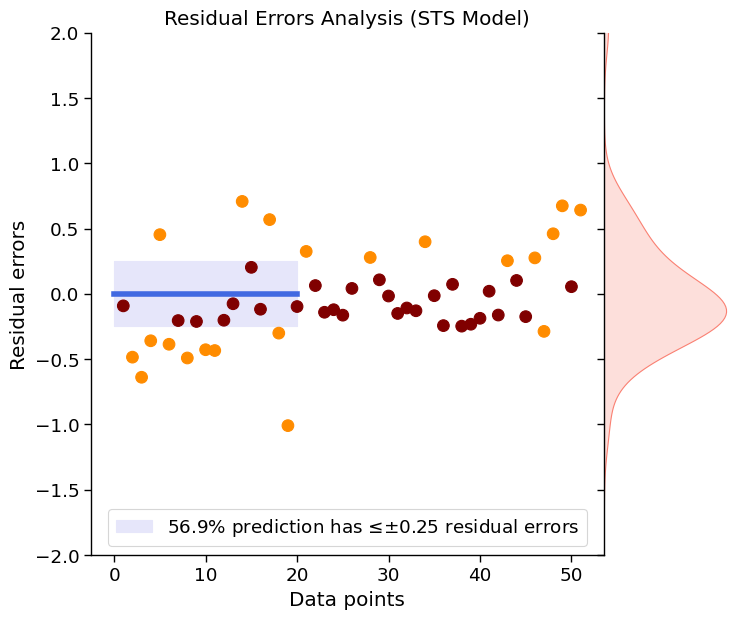

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_120-128_k_1_bys_val_0.21767
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Mean absolute error = 0.283
Mean squared error = 0.218
Median absolute error = 0.164
Variance score = 0.2162
Explained variance score = 0.785
R2 score = 0.784


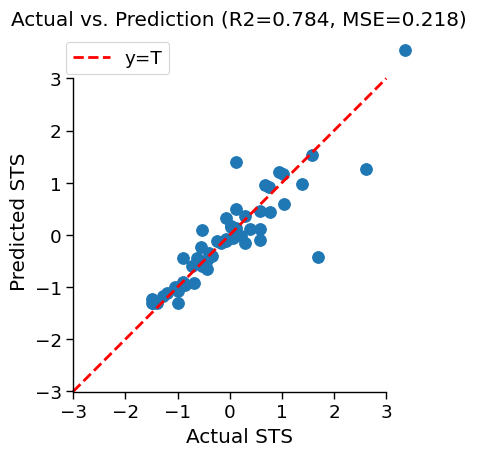

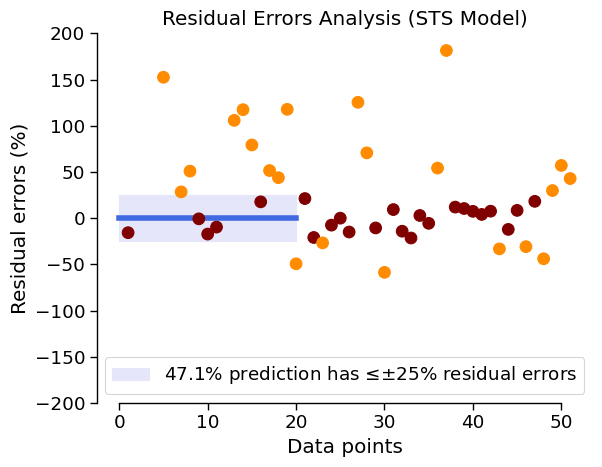

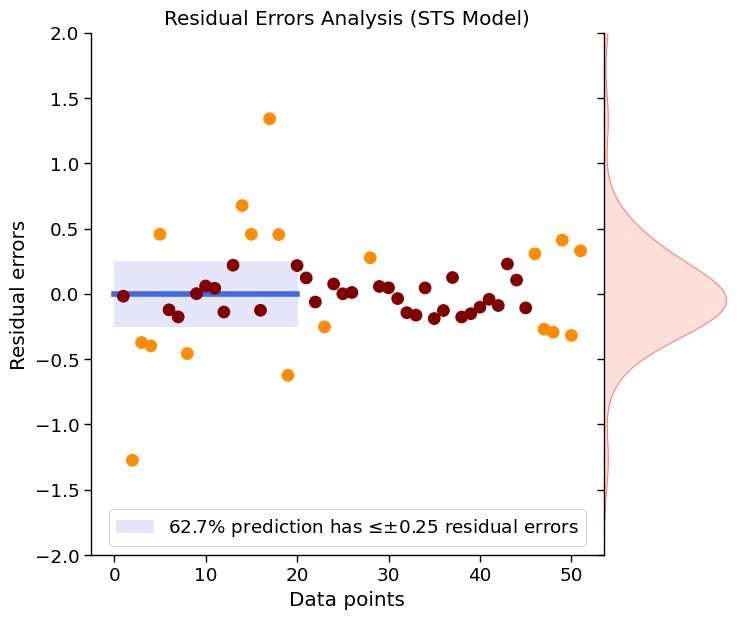

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_104-56_k_1_bys_val_0.21916
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Mean absolute error = 0.33
Mean squared error = 0.219
Median absolute error = 0.202
Variance score = 0.2188
Explained variance score = 0.783
R2 score = 0.782


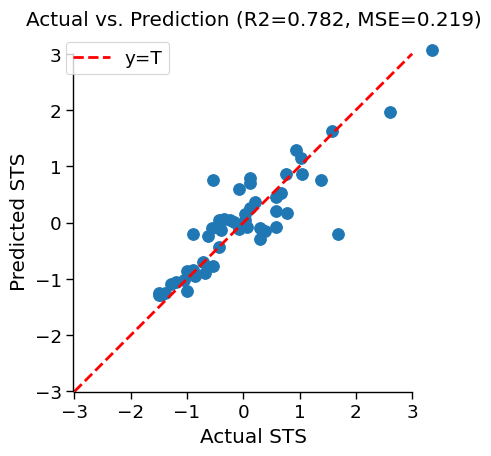

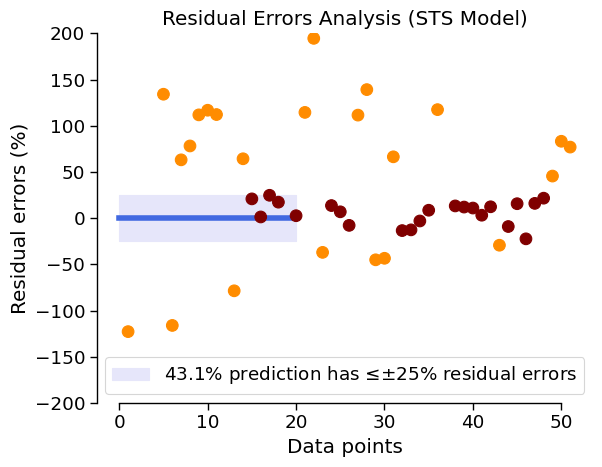

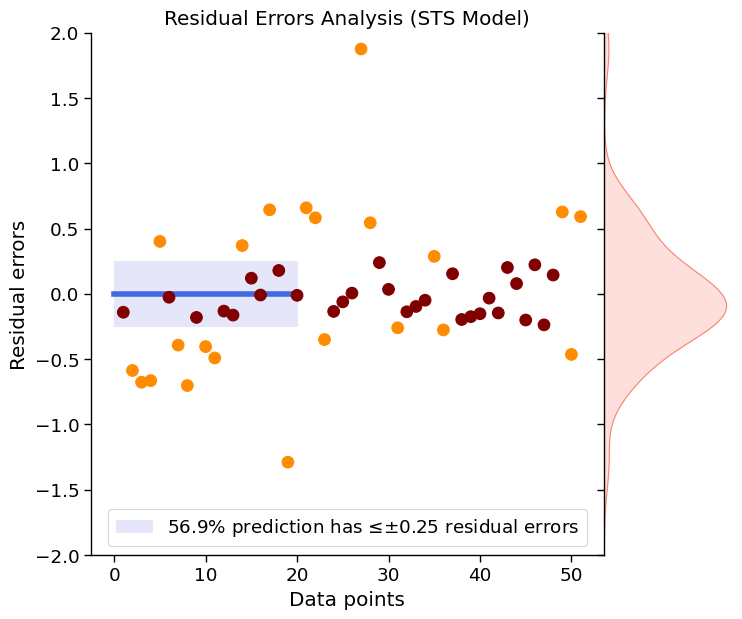

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_128-128_k_1_bys_val_0.22977
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Mean absolute error = 0.324
Mean squared error = 0.23
Median absolute error = 0.204
Variance score = 0.2288
Explained variance score = 0.773
R2 score = 0.772


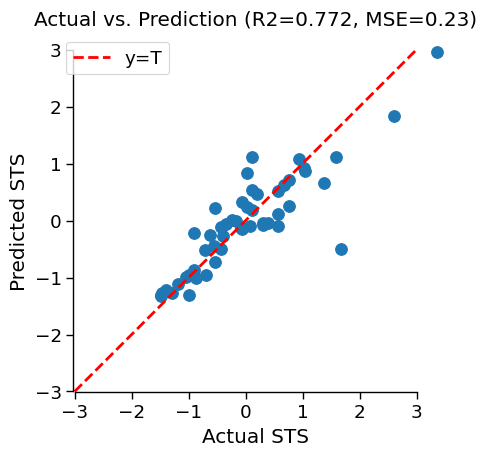

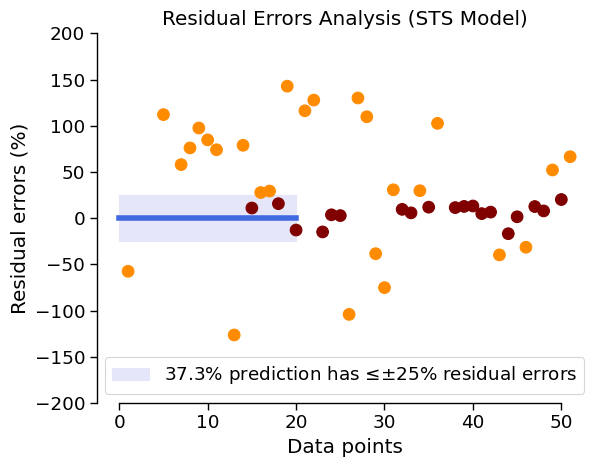

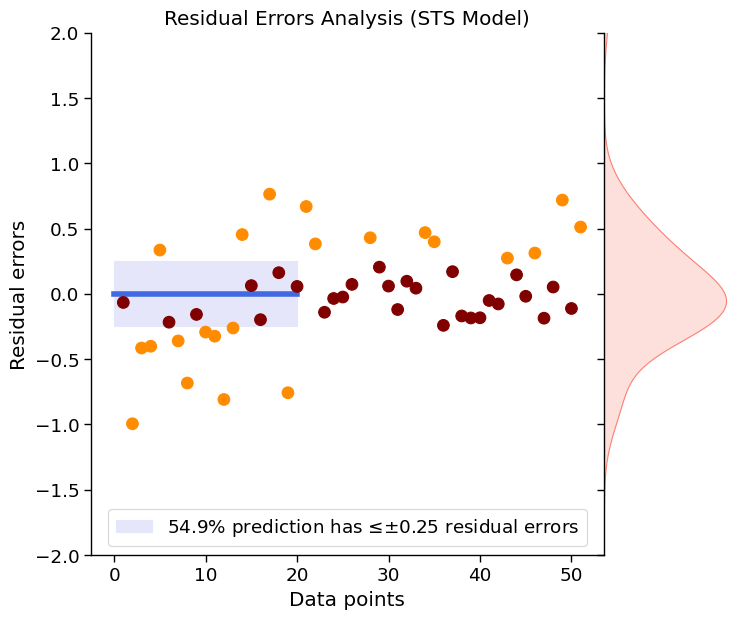

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_128-112_k_1_bys_val_0.23479
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Mean absolute error = 0.315
Mean squared error = 0.235
Median absolute error = 0.199
Variance score = 0.233
Explained variance score = 0.769
R2 score = 0.767


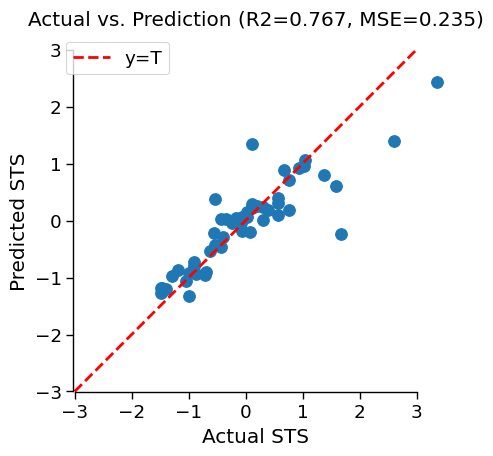

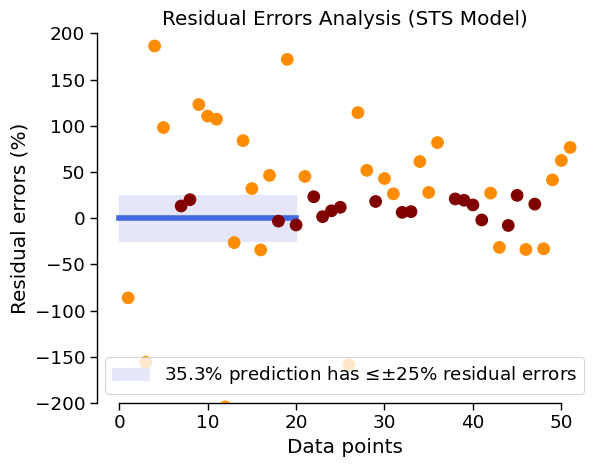

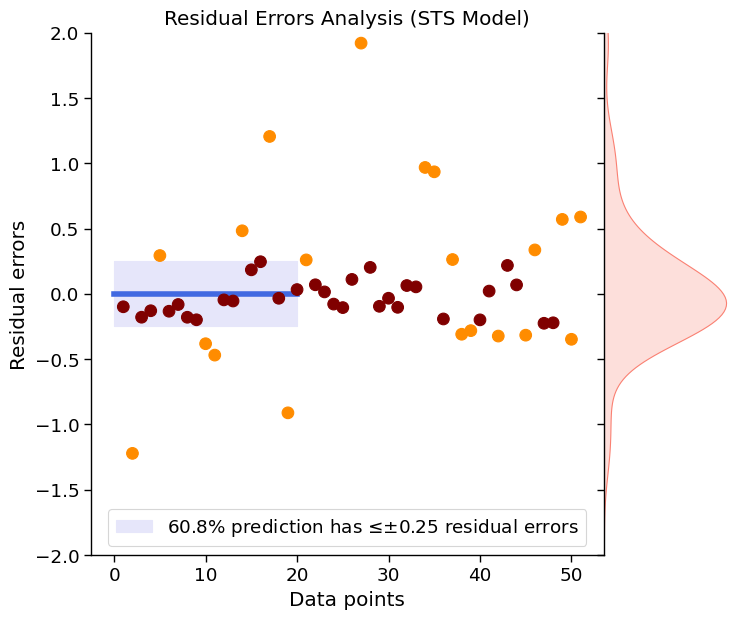

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_128-48_k_1_bys_val_0.24555
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Mean absolute error = 0.361
Mean squared error = 0.246
Median absolute error = 0.266
Variance score = 0.2385
Explained variance score = 0.763
R2 score = 0.756


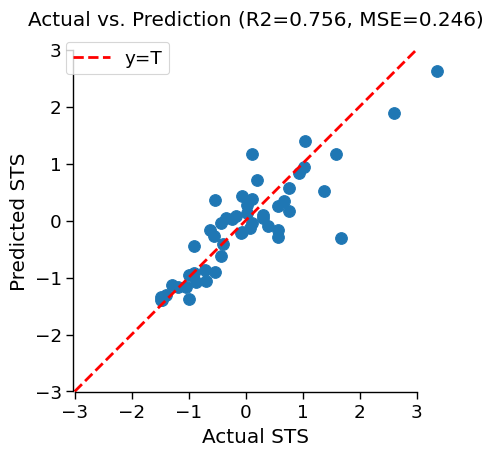

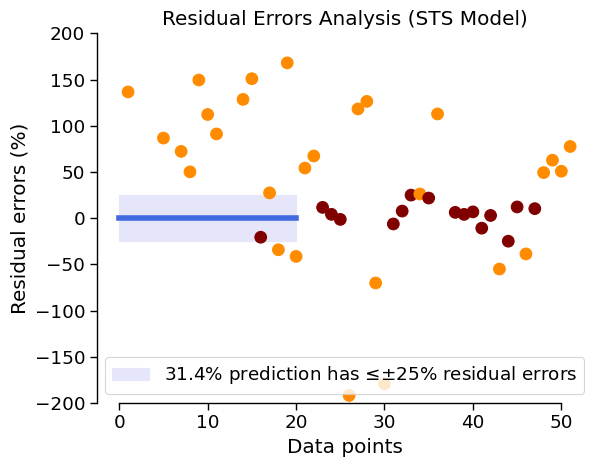

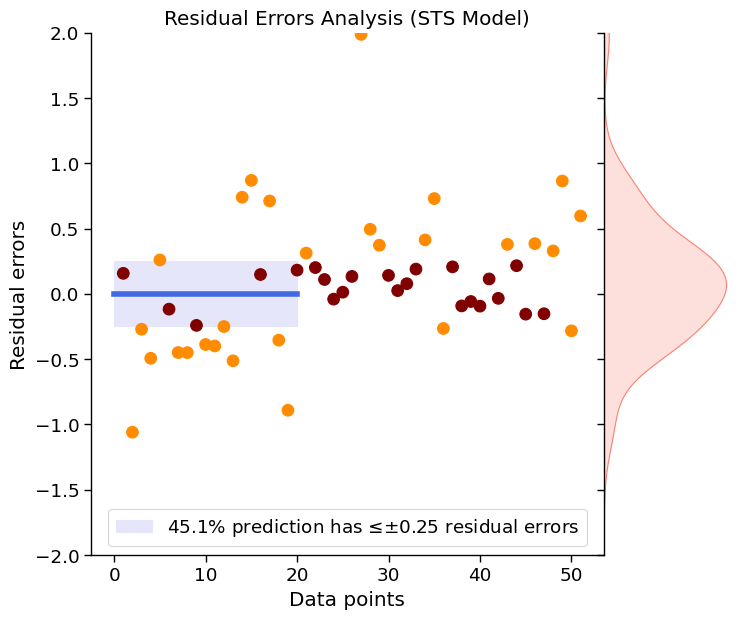

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_120-32_k_1_bys_val_0.26108
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Mean absolute error = 0.353
Mean squared error = 0.261
Median absolute error = 0.217
Variance score = 0.2606
Explained variance score = 0.741
R2 score = 0.741


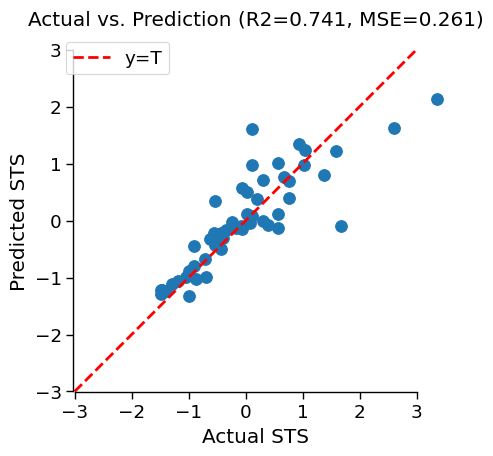

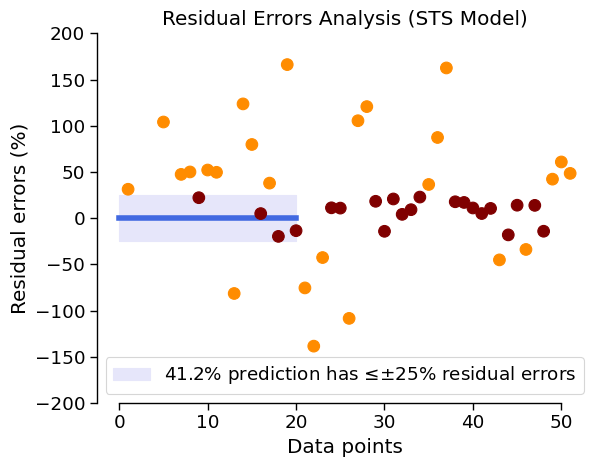

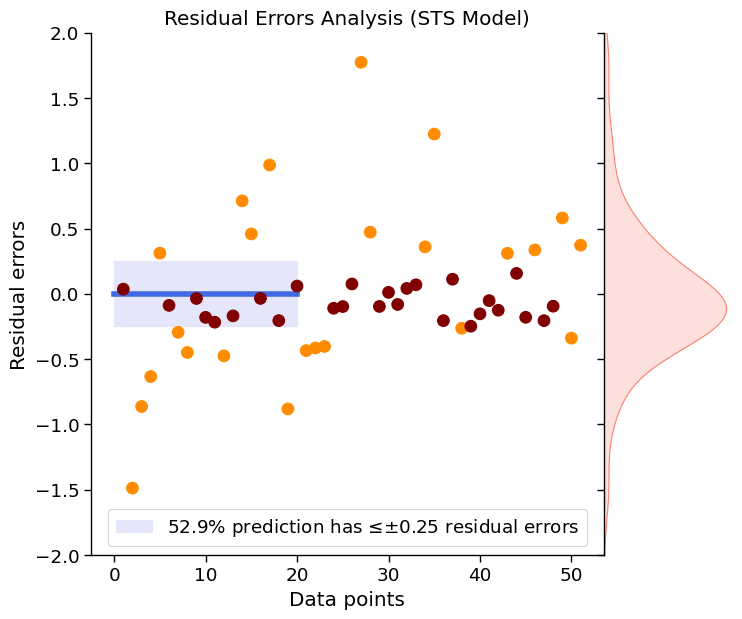

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_128-56_k_1_bys_val_0.26198
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Mean absolute error = 0.34
Mean squared error = 0.262
Median absolute error = 0.221
Variance score = 0.2609
Explained variance score = 0.741
R2 score = 0.74


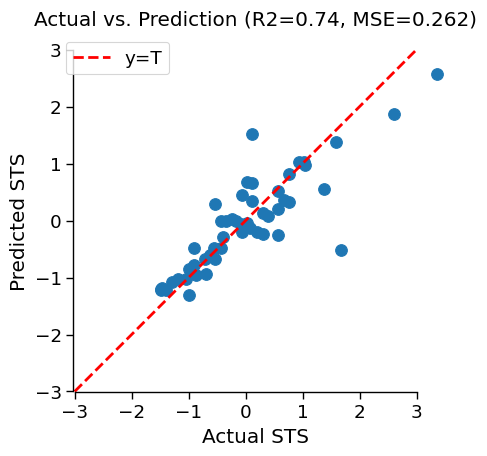

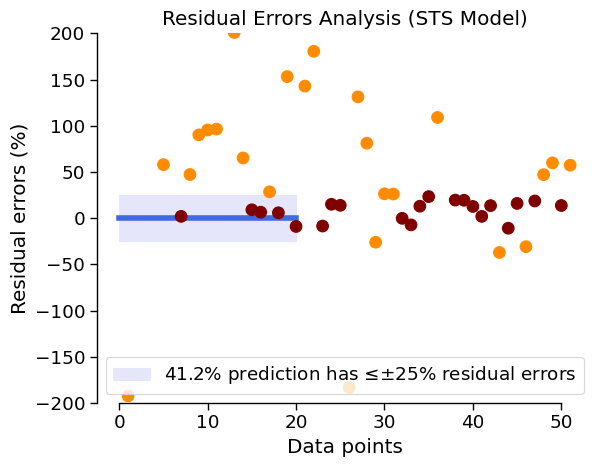

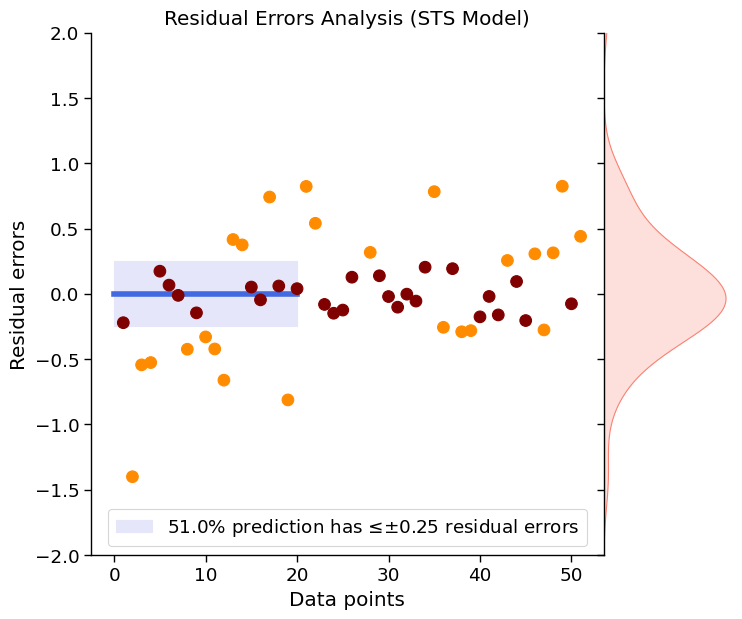

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models/my_model_128-40_k_1_bys_val_0.26788
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Mean absolute error = 0.341
Mean squared error = 0.268
Median absolute error = 0.234
Variance score = 0.2629
Explained variance score = 0.739
R2 score = 0.734


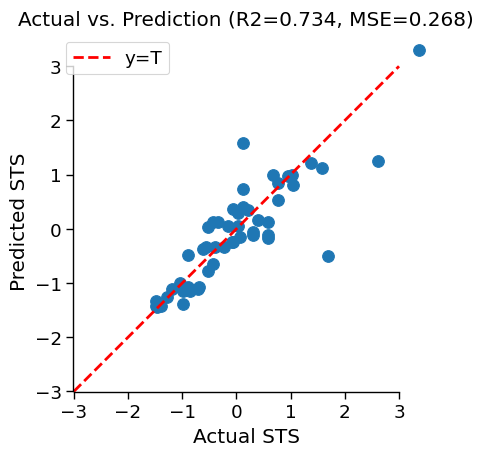

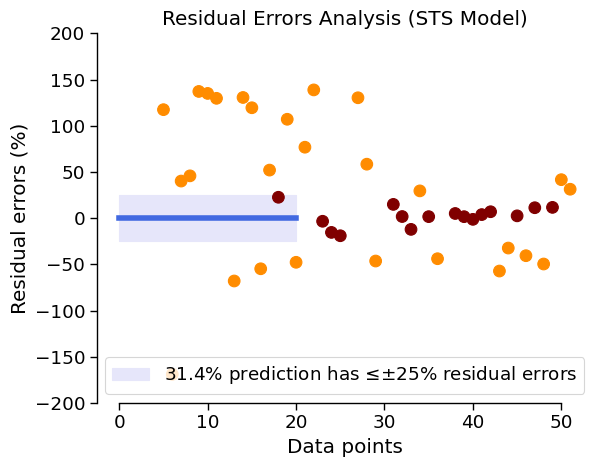

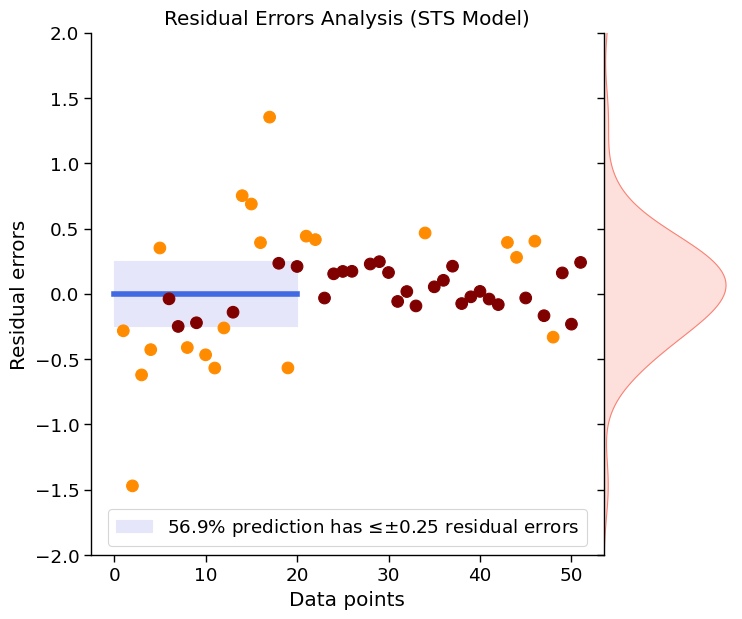

/content/drive/MyDrive/Colab Notebooks/STS Prediction/K=1 Actf=relu Best Models
/content/drive/MyDrive/Colab Notebooks/STS Prediction


In [ ]:
# 1 selecting best models

from keras_tuner import BayesianOptimization
import os
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import sklearn.metrics as sm
import pandas as pd
from tensorflow import keras


import tensorflow as tf
import datetime, os


%load_ext tensorboard


#modeling parameters
model_num=10 #how many model want to save
iter_num=38 #max iteration number
tr_fld_num=1 # Training data K-fold number
epchs=600 #800

stp=0 #0=STS, 1=OR, 2=NR, 3=PR
inpt_num=10 #how mamy input the model has

dir_name='my_dir1' # directory name wherer the models will be saved
new_folder="K="+str(tr_fld_num)+" Actf="+str(actf)+" Best Models"


#ploting parameters
name="STS"
unt="" #" (mg/L)"
data_points=20 #total testing data point (rounded)
err_lim1=25 #residula % error limit shown in the plot
err_lim=0.25 #residula error limit shown in the plot
xmax=3


# Parent Directory path
parent_dir = "/content/drive/MyDrive/Colab Notebooks/STS Prediction/"


#output statistical info
norm_prmt = pd.read_csv(parent_dir+'Normalizing_parameters.csv').values
mean9=norm_prmt[inpt_num,stp] #row,col
stdev9=norm_prmt[2*inpt_num+1,stp]


data = pd.read_csv(parent_dir+'K=5 folds '+name+'/Training_data_'+name+'-fold'+str(tr_fld_num)+'.csv')
dataset1= data.values
X_training = dataset1[:,0:inpt_num]
Y_training = dataset1[:,inpt_num]


data2 = pd.read_csv(parent_dir+'K=5 folds '+name+'/Testing_data_'+name+'-fold'+str(tr_fld_num)+'.csv') #testing with unused k-fold data

dataset2= data2.values
X_testing = dataset2[:,0:inpt_num]
Y_testing = dataset2[:,inpt_num]

X_valid=X_testing
Y_valid=Y_testing


tuner_hb = BayesianOptimization(
            hypermodel=build,
            directory=dir_name,
            max_trials=iter_num,
            max_retries_per_trial=1,
            objective='val_loss',
            seed=42,
            overwrite=True,
            executions_per_trial=1
        )

# Instead of tuning the number of epochs, we use Early Stopping.
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', start_from_epoch=500, patience=25)


logdir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)


tuner_hb.search(X_training, Y_training, epochs=epchs, validation_data=(X_valid, Y_valid), verbose=0,
                callbacks=[early_stopping])


models = tuner_hb.get_best_models(num_models=3)
best_model = models[0]
best_model.evaluate(X_testing, Y_testing)


###saving the models###
models = tuner_hb.get_best_models(num_models=model_num)


# Parent Directory path

# Path
path1 = os.path.join(parent_dir, new_folder)
os.mkdir(path1)

model_names=["" for x in range(model_num)] #np.zeros(10)

val3=range(model_num)
for l in val3:
  best_model = models[l]
  best_hps=tuner_hb.get_best_hyperparameters(model_num)

  neuron_arch=neuron_arch=str(best_hps[l].get('units1'))+'-'+str(best_hps[l].get('units2'))+'-'+str(best_hps[l].get('units3'))+'-'+str(best_hps[l].get('units4'))

  model_score="{:.5f}".format(best_model.evaluate(X_testing, Y_testing)[0]) #str(best_model.evaluate(X_testing, Y_testing)[0])


  model_names[l]="my_model_"+neuron_arch+"_k_"+str(tr_fld_num)+"_bys_val_"+model_score


  #Saving and loading a model

  best_model.save(path1+"/"+model_names[l]+".keras") #.h5 .keras


%cd $path1
file_name='filenames'
my_submission = pd.DataFrame({'Names':model_names, 'K':[tr_fld_num for x in range(model_num)]})
my_submission.to_csv('{}.csv'.format(file_name),index=False)





###Model Analysis###


#%cd $path1

###for generating plot of diffrent k-fold###


#data = pd.read_csv('Lab_data.csv')
allfiles = pd.read_csv('filenames.csv')
dataset3= allfiles.values
file = dataset3[:,0]

#model_names=["" for x in range(10)] #np.zeros(10)
MAE=["" for x in range(len(file))]
MSE=["" for x in range(len(file))]
R2=["" for x in range(len(file))]
RES=["" for x in range(len(file))]
RES_P=["" for x in range(len(file))]

# Parent Directory path


val1=range(len(file))
for k in val1:


  # Directory
  directory = file[k]
  # Path
  #path = os.path.join(parent_dir, directory)
  path = os.path.join(path1+'/', directory)
  os.mkdir(path)
  %cd $path

  #Loading a model
  #model = keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/As Removal (Lab)/'+file[k]+'.h5')
  #model = keras.models.load_model(path1+'/'+file[k]+'.keras') # .h5 .keras
  model = keras.models.load_model(path1+'/'+file[k]+'.keras',compile=False) # .h5 .keras
  model.compile(optimizer='adam', loss='mse', metrics=['mse'])
  result_all=model.predict(X_testing)
  Y_pred_all = np.round(result_all,3)

  MAE[k]=round(sm.mean_absolute_error(Y_testing, Y_pred_all[:,0]), 3)
  MSE[k]=round(sm.mean_squared_error(Y_testing, Y_pred_all[:,0]), 3)
R2[k]=round(sm.r2_score(Y_testing, Y_pred_all[:,0]), 3)

  plt.ylim(-xmax,xmax)
  plt.xlim(-xmax,xmax)
  # add y=x line
  plt.plot([-xmax,xmax],[-xmax,xmax], label='y=T', lw=2, color='red', linestyle='dashed')
  plt.scatter(Y_testing, Y_pred_all[:,0],s=70)
  plt.title('Actual vs. Prediction (R2='+str(R2[k])+', MSE='+str(MSE[k])+')')
  plt.xlabel('Actual '+name+unt) #Stress')
  plt.ylabel('Predicted '+name+unt) #Strss')
  plt.legend()
  sns.despine( offset=-12,trim=True)
  plt.axis('scaled')
  plt.tight_layout()
  #plt.show()
  plt.savefig('Actual_vs_Prediction.pdf')
  plt.figure()


  with open("Prediction_summery.txt", "a") as f:
    print("Mean absolute error =", round(sm.mean_absolute_error(Y_testing, Y_pred_all[:,0]), 3), file=f)
    print("Mean squared error =", round(sm.mean_squared_error(Y_testing, Y_pred_all[:,0]), 3), file=f)
    print("Median absolute error =", round(sm.median_absolute_error(Y_testing, Y_pred_all[:,0]), 3), file=f)
    print("Variance score =", round(np.var(np.array(Y_testing-Y_pred_all[:,0])), 4), file=f)
    print("Explained variance score =", round(sm.explained_variance_score(Y_testing, Y_pred_all[:,0]), 3), file=f)
    print("R2 score =", round(sm.r2_score(Y_testing, Y_pred_all[:,0]), 3), file=f)

  print("Mean absolute error =", round(sm.mean_absolute_error(Y_testing, Y_pred_all[:,0]), 3))
  print("Mean squared error =", round(sm.mean_squared_error(Y_testing, Y_pred_all[:,0]), 3))
  print("Median absolute error =", round(sm.median_absolute_error(Y_testing, Y_pred_all[:,0]), 3))
  print("Variance score =", round(np.var(np.array(Y_testing-Y_pred_all[:,0])), 4))
  print("Explained variance score =", round(sm.explained_variance_score(Y_testing, Y_pred_all[:,0]), 3))
  print("R2 score =", round(sm.r2_score(Y_testing, Y_pred_all[:,0]), 3))



  ###normalized error###

  red_count1=0;


  # add y=0 line
  plt.plot([0,data_points],[0,0], lw=4, color='royalblue',zorder=2)

  #residual_prc=(Y_testing-Y_pred_all)*100/Y_testing
  residual_prc1=(Y_testing.reshape(len(Y_testing),1)-Y_pred_all)*100/Y_testing.reshape(len(Y_testing),1)


  colors1=[None]*len(Y_testing)

  val=range(len(Y_testing))
  for i in val:
    if abs(residual_prc1[i])>err_lim1:
  	  colors1[i]='darkorange'
  	  red_count1=red_count1+1
    else:
  	  colors1[i]='maroon'

  plt.scatter(np.linspace(1, len(residual_prc1), len(residual_prc1)),residual_prc1,marker='o',c = colors1,s=70,zorder=5)


  #plt.scatter(np.linspace(1, len(residual_prc), len(residual_prc)),residual_prc, color = 'brown', s=70)
  plt.ylim(-200,200)
  #plt.ylim(-2,2)

  plt.fill_between([0,data_points], -err_lim1, err_lim1, label="{:.1f}".format((len(Y_testing)-red_count1)*100/len(Y_testing))+'% prediction has ≤'+'$±$'+"{:.0f}".format(err_lim1)+'% residual errors', color='lavender') #, alpha=0.1)

  RES_P[k]=round((len(Y_testing)-red_count1)*100/len(Y_testing),3)

  sns.set_context("paper", font_scale=1.5)
  #plt.xlabel('Actual Stress', {'size':'20'})
  plt.xlabel('Data points')
  #plt.ylabel('Residual errors (%)')
  plt.ylabel('Residual errors (%)')
  plt.title('Residual Errors Analysis ('+name+' Model)')
  sns.despine(offset=0,trim=True)
  #plt.axis('auto')
  #plt.tight_layout()
  plt.legend(loc='lower center')

  plt.savefig('Residual_errors_'+name+'1.pdf')
  plt.show()

  #sns.set(style="darkgrid")


  red_count=0;
  residual_prc=(Y_testing.reshape(len(Y_testing),1)-Y_pred_all)
  colors=[None]*len(Y_testing)


  val=range(len(Y_testing))
  for i in val:
    if abs(residual_prc[i])>err_lim:
  	  colors[i]='darkorange'
  	  red_count=red_count+1
    else:
  	  colors[i]='maroon'

  df = pd.DataFrame({
  	#'X': np.linspace(1, len(residual_prc), len(residual_prc)).reshape(len(residual_prc),1),
  	'Data points': np.linspace(1, len(residual_prc), len(residual_prc)),
  	'Residual errors': residual_prc.reshape(1,len(residual_prc))[0],
  	'Colors': colors})
  #df.head(n=3)
  df.head(n=3)

  #g=sns.jointplot(x="X",
  g = sns.JointGrid(x="Data points",
  			y="Residual errors",
  			#edgecolor="white",
  			data=df,
  			space=0,
  			height=7.5,
  			ratio=4,
  			#hue="Colors",);
  			);

  #g.plot_joint(sns.scatterplot)
  g.plot_joint(plt.scatter,marker='o',c = colors,s=70,zorder=5)
  #g.plot_marginals(sns.displot, kde=True, color=".5")

  g.plot_marginals(sns.kdeplot,color="salmon",fill=True)
  g.ax_marg_x.remove()


  # add y=0 line
  plt.plot([0,data_points],[0,0], lw=4, color='royalblue',zorder=2)

  #Shading err_limit ranges
  plt.fill_between([0,data_points], -err_lim, err_lim, label="{:.1f}".format((len(Y_testing)-red_count)*100/len(Y_testing))+'% prediction has ≤'+'$±$'+"{:.2f}".format(err_lim)+' residual errors', color='lavender') #, alpha=0.1)

  RES[k]=round((len(Y_testing)-red_count)*100/len(Y_testing),3)

  plt.ylim(-2,2)


  plt.title('Residual Errors Analysis ('+name+' Model)')
  #sns.despine(offset=0,trim=True)
  #plt.axis('auto')
  #plt.tight_layout()
  plt.legend(loc='lower center')

  plt.savefig('Residual_errors_'+name+'.pdf')
  plt.show()

  file_name='Preditions'
  my_submission = pd.DataFrame({'Actual':Y_testing,'Predection':Y_pred_all[:,0],'RErr':(Y_testing-Y_pred_all[:,0]),'RErr%':(Y_testing-Y_pred_all[:,0])*100/Y_testing,'Actual(real)':Y_testing*stdev9+mean9,'Predection(real)':Y_pred_all[:,0]*stdev9+mean9 })
  my_submission.to_csv('{}.csv'.format(file_name),index=False)
  #print('File has been saved')

  %cd $path1


NS1=np.round((R2+RES/np.max(100)+RES_P/np.max(100))/3,3)
NS2=np.round((R2+RES/np.max(100))/2,3)
NS3=np.round((R2+RES_P/np.max(100))/2,3)

file_name='Perfornace_Summary'
my_submission = pd.DataFrame({'Name':file,'MAE':MAE,'MSE':MSE,'R2':R2,'Preditions With Below '+"{:.2f}".format(err_lim)+' RErr':RES,'Preditions With Below '+"{:.0f}".format(err_lim1)+' RErr%':RES_P,'Score(all)':NS1,'Score(RES)':NS2,'Score(RES_P)':NS3 })
my_submission.to_csv('{}.csv'.format(file_name),index=False)

%cd $parent_dir

from google.colab import drive
drive.flush_and_unmount()


from google.colab import runtime
runtim.unassign()